In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

In [17]:
np.random.seed(42)

n = 500

study_hours = np.random.uniform(1, 10, n)
attendance = np.random.uniform(50, 100, n)
previous_score = np.random.uniform(30, 100, n)
sleep_hours = np.random.uniform(4, 9, n)
assignments = np.random.randint(0, 11, n)
extracurricular = np.random.randint(0, 2, n)

performance_score = (
    0.35 * study_hours
    + 0.25 * attendance
    + 0.25 * previous_score
    + 0.05 * sleep_hours
    + 0.08 * assignments
    + 0.02 * extracurricular * 100
)

threshold = np.median(performance_score)

passed = (performance_score >= threshold).astype(int)

df = pd.DataFrame({
    "StudyHours": study_hours,
    "Attendance": attendance,
    "PreviousScore": previous_score,
    "SleepHours": sleep_hours,
    "AssignmentsCompleted": assignments,
    "Extracurricular": extracurricular,
    "Passed": passed
})


In [18]:
df["Passed"].value_counts()

,count
Passed,
0,250
1,250


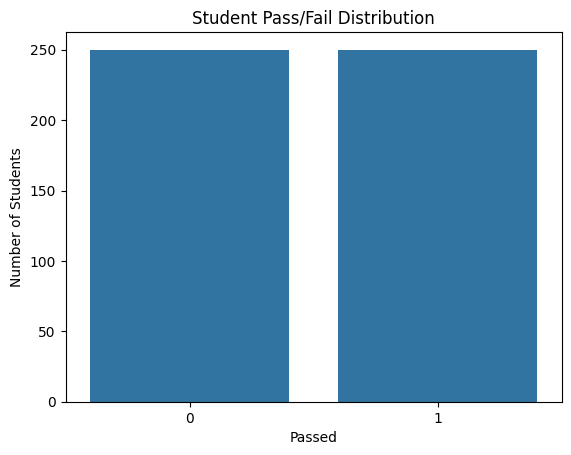

In [19]:
sns.countplot(
    x="Passed",
    data=df
)

plt.title("Student Pass/Fail Distribution")
plt.xlabel("Passed")
plt.ylabel("Number of Students")
plt.show()

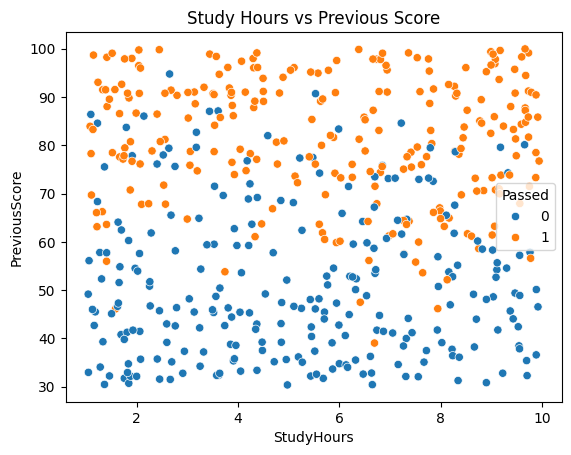

In [20]:
sns.scatterplot(
    x="StudyHours",
    y="PreviousScore",
    hue="Passed",
    data=df
)

plt.title("Study Hours vs Previous Score")
plt.show()

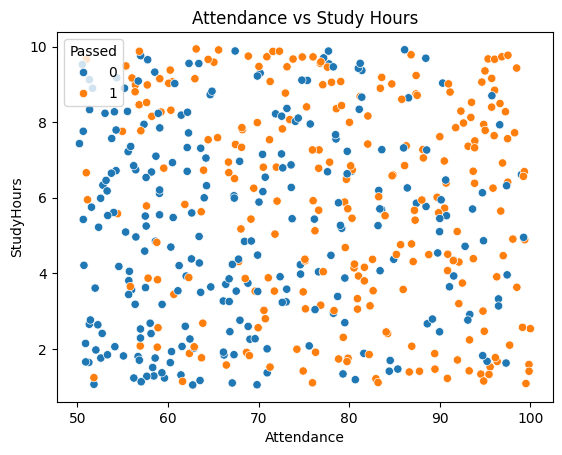

In [21]:
sns.scatterplot(
    x="Attendance",
    y="StudyHours",
    hue="Passed",
    data=df
)

plt.title("Attendance vs Study Hours")
plt.show()

In [ ]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")
plt.show()

In [24]:
X = df.drop("Passed", axis=1)

y = df["Passed"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
X_train

,StudyHours,Attendance,PreviousScore,SleepHours,AssignmentsCompleted,Extracurricular
163,5.821972,61.861340,82.045578,6.484817,0,1
469,9.669003,73.802520,84.766984,4.130984,3,0
42,1.309497,61.432140,52.312675,6.836561,6,1
426,4.973775,63.433868,30.345799,6.941011,4,0
147,5.524111,83.955116,76.091628,8.130338,8,0
...,...,...,...,...,...,...
126,8.362133,73.126736,36.089073,5.004668,6,0
207,6.971516,90.493722,61.213189,5.080191,8,1
27,5.628110,63.670354,89.118458,5.536450,10,0
422,1.820855,94.727611,32.910100,7.097947,5,1


In [28]:
model = DecisionTreeClassifier(
    random_state=42
)

model.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(random_state=42)

In [29]:
y_pred = model.predict(X_test)

In [30]:
y_pred

array([1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0])

In [31]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.93


In [32]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.90      0.93        50
           1       0.91      0.96      0.93        50

    accuracy                           0.93       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100



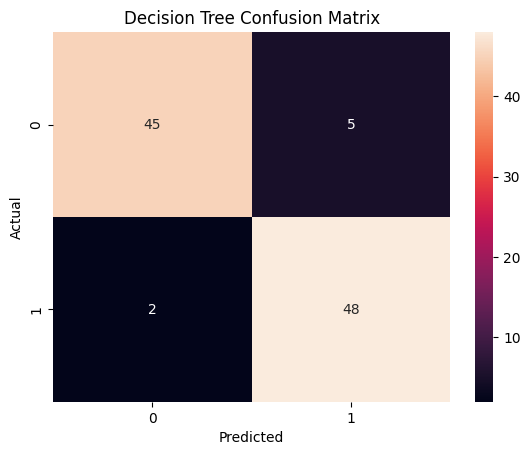

In [33]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

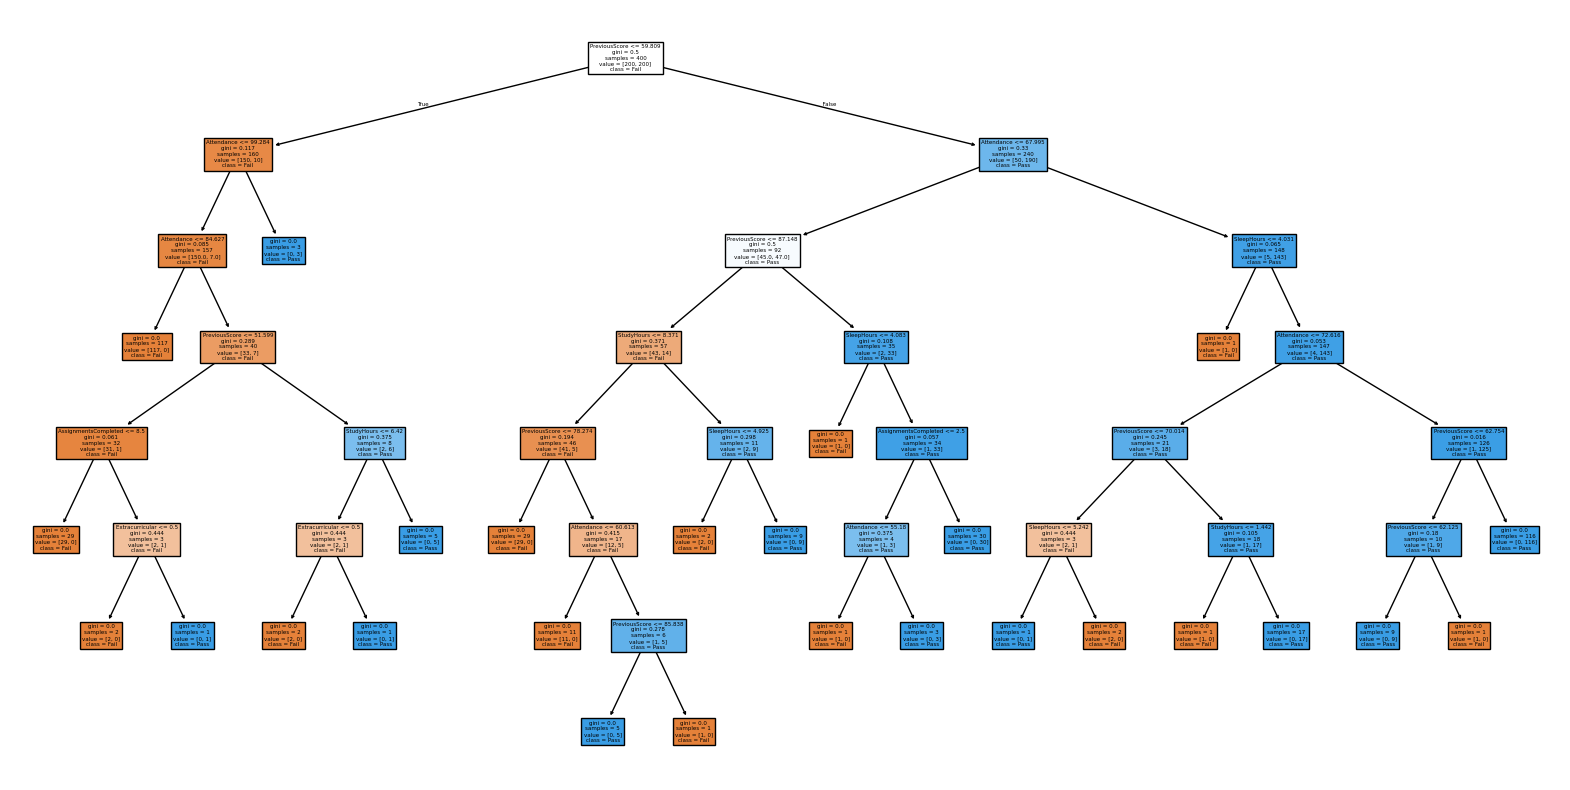

In [34]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True
)

plt.show()

In [36]:
depths = range(1, 16)

train_scores = []
test_scores = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_scores.append(
        model.score(X_train, y_train)
    )

    test_scores.append(
        model.score(X_test, y_test)
    )

In [38]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                Feature  Importance
2         PreviousScore    0.686028
1            Attendance    0.191369
0            StudyHours    0.062463
3            SleepHours    0.041581
5       Extracurricular    0.013333
4  AssignmentsCompleted    0.005227


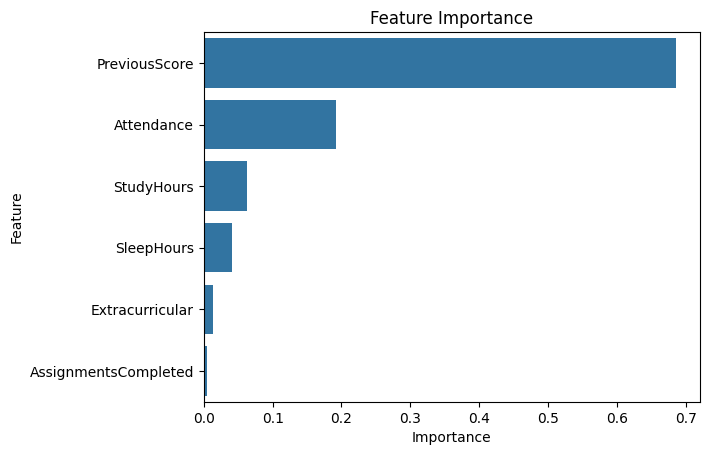

In [39]:
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")
plt.show()